# Getting Started with `entropy-invariant`

`entropy-invariant` estimates differential entropy, mutual information, conditional
mutual information, and partial information decomposition from continuous data, in a
way that's **invariant under change of variables**: rescale, shift, or change the units
of your data, and the estimates don't move.

That invariance comes from **how the data is normalized before any k-NN search
happens** -- each variable is divided by its own *invariant measure*, the median
nearest-neighbor distance, rather than by `std` (the usual choice, and the thing that
breaks under outliers and heavy tails). The normalization is the actual contribution
of this package; which k-NN algorithm you run *after* normalizing is a separate
question.

For entropy of a single variable there's only one sensible algorithm (Kozachenko-
Leonenko). But mutual information and conditional mutual information can be estimated
two different ways once the data is normalized:

- **naively differencing entropies** -- `I(X;Y) = H(X) + H(Y) - H(X,Y)`, three
  independent k-NN searches, each with its own bias
- **KSG / Frenzel-Pompe** -- one shared k-NN search radius reused across all terms,
  so the leading-order bias cancels algebraically instead of compounding

**`method="inv_ksg"` combines both ideas and is the default** for every MI-derived
quantity in this package (`mutual_information`, `conditional_mutual_information`,
`conditional_entropy`, `normalized_mutual_information`, `interaction_information`,
`information_quality_ratio`, the PID functions, and the `MI`/`CMI` matrices). The
plain `"inv"` plug-in estimator is still available if you specifically need the
individual entropy terms rather than just their difference -- but for MI/CMI/PID
themselves, `inv_ksg` is both more accurate and the recommended choice.

This notebook is a hands-on tour:

1. [Normalization: why differential entropy needs it](#1.-Normalization:-why-differential-entropy-needs-it)
2. [Bias cancellation: why `inv_ksg` beats naive differencing](#2.-Bias-cancellation:-why-inv_ksg-beats-naive-differencing)
3. [Why not just use `std` normalization? A few extreme outliers](#3.-Why-not-just-use-std-normalization?-A-few-extreme-outliers)
4. [Mutual information and conditional entropy](#4.-Mutual-information-and-conditional-entropy)
5. [Multivariate quantities: joint entropy and MI matrices](#5.-Multivariate-quantities:-joint-entropy-and-MI-matrices)
6. [Partial information decomposition](#6.-Partial-information-decomposition-(redundancy,-unique,-synergy))
7. [Where to go next](#7.-Where-to-go-next)

Paper: *An Invariant Measure for Differential Entropy: From Kullback-Leibler Divergence
to Scale-Invariant Information Theory*, Entropy 2026, 28(3), 301.
[https://www.mdpi.com/1099-4300/28/3/301](https://www.mdpi.com/1099-4300/28/3/301)


In [1]:
# !pip install entropy-invariant

import numpy as np
import matplotlib.pyplot as plt

from entropy_invariant import (
    entropy,
    entropy_knn,
    mutual_information,
    mutual_information_ksg,
    conditional_entropy,
    conditional_mutual_information,
    conditional_mutual_information_ksg,
    redundancy,
    unique,
    synergy,
    MI,
)

rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (6, 4)


## 1. Normalization: why differential entropy needs it

Draw a continuous variable and estimate its entropy with the classical k-NN
(Kozachenko-Leonenko) estimator on the raw, un-normalized data (`entropy_knn`). Then
rescale the *same* variable (a harmless change of units) and estimate again.


In [2]:
n = 2000
x = rng.uniform(0, 1, n)

h_raw = entropy_knn(x)
print(f"H(x), no normalization           = {h_raw:.4f}")

# Just a change of units: multiply by 1e5 and shift. Same information content, same distribution shape.
x_rescaled = 1e5 * x - 123.456
h_raw_rescaled = entropy_knn(x_rescaled)
print(f"H(1e5*x - 123.456), no normalization = {h_raw_rescaled:.4f}")
print(f"\nDifference: {h_raw_rescaled - h_raw:.4f} nats -- for a variable that carries the exact same information!")


H(x), no normalization           = -0.0080
H(1e5*x - 123.456), no normalization = 11.5049

Difference: 11.5129 nats -- for a variable that carries the exact same information!


That's the problem: a rescaled version of `x` reads as carrying several *more* nats
of information than `x` itself, purely from a change of units. `entropy(x)` -- default
`method="inv"` -- fixes this by dividing by the invariant measure (median
nearest-neighbor distance) before running the same k-NN estimator.


In [3]:
h_inv = entropy(x)                 # method="inv" is the default
h_inv_rescaled = entropy(x_rescaled)

print(f"H(x)                  = {h_inv:.6f}")
print(f"H(1e5*x - 123.456)     = {h_inv_rescaled:.6f}")
print(f"Difference: {h_inv_rescaled - h_inv:.2e} nats -- effectively zero (floating point noise)")


H(x)                  = 1.009332
H(1e5*x - 123.456)     = 1.009332
Difference: 1.28e-13 nats -- effectively zero (floating point noise)


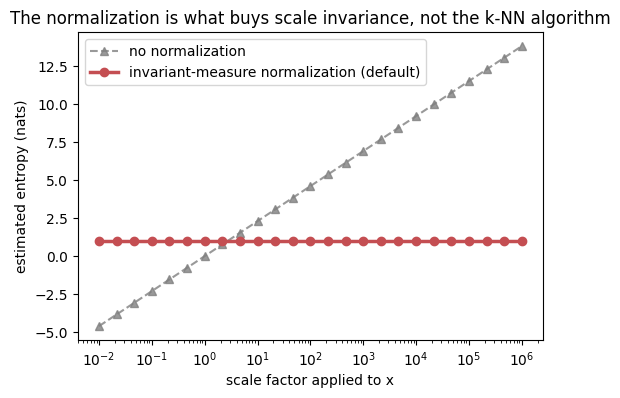

In [4]:
scales = np.logspace(-2, 6, 25)
h_raw_vals = [entropy_knn(s * x) for s in scales]
h_inv_vals = [entropy(s * x) for s in scales]

fig, ax = plt.subplots()
ax.plot(scales, h_raw_vals, "^--", label="no normalization", color="gray", alpha=0.8)
ax.plot(scales, h_inv_vals, "o-", label="invariant-measure normalization (default)", color="#C44E52", linewidth=2.5)
ax.set_xscale("log")
ax.set_xlabel("scale factor applied to x")
ax.set_ylabel("estimated entropy (nats)")
ax.set_title("The normalization is what buys scale invariance, not the k-NN algorithm")
ax.legend()
plt.show()


## 2. Bias cancellation: why `inv_ksg` beats naive differencing

Normalization alone doesn't make **mutual information** robust. `I(X;Y) = H(X) + H(Y)
- H(X,Y)` computed as three independent, invariant-normalized entropy estimates still
carries three independent finite-sample biases that don't cancel -- this shows up as
systematic drift whenever the data has outliers or lies close to a lower-dimensional
manifold.

`inv_ksg` fixes the *other* half of the problem: instead of differencing three
separately-estimated entropies, it finds one shared k-NN radius in the joint space and
reuses it to count neighbors in each marginal (the KSG trick, extended to conditional
MI by Frenzel & Pompe). The bias cancels algebraically instead of compounding.

A quick demonstration: inject outliers into two variables built from a common latent
confounder, and compute their conditional mutual information given that confounder --
the true value should stay near 0 regardless of contamination.


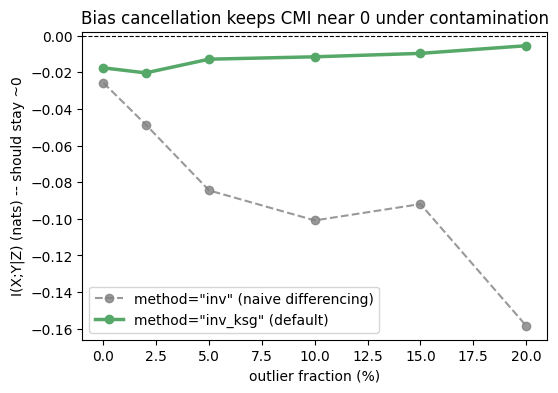

At 20% outliers: inv=-0.1583 nats,  inv_ksg=-0.0055 nats (closer to the true ~0)


In [5]:
rng2 = np.random.default_rng(42)
n = 3000
z = rng2.standard_normal(n)
x_base = z + 0.3 * rng2.standard_normal(n)
y_base = z + 0.3 * rng2.standard_normal(n)

outlier_fracs = [0, 0.02, 0.05, 0.10, 0.15, 0.20]
cmi_plugin, cmi_ksg = [], []

for frac in outlier_fracs:
    x, y, zc = x_base.copy(), y_base.copy(), z.copy()
    n_spikes = int(frac * n)
    if n_spikes > 0:
        for arr in [x, y, zc]:
            idx = rng2.choice(n, n_spikes, replace=False)
            arr[idx] += 50 * rng2.choice([-1, 1], size=n_spikes)
    cmi_plugin.append(conditional_mutual_information(x, y, zc, method="inv"))
    cmi_ksg.append(conditional_mutual_information(x, y, zc))  # default: inv_ksg

fig, ax = plt.subplots()
pct = [f * 100 for f in outlier_fracs]
ax.plot(pct, cmi_plugin, "o--", label='method="inv" (naive differencing)', color="gray", alpha=0.8)
ax.plot(pct, cmi_ksg, "o-", label='method="inv_ksg" (default)', color="#55A868", linewidth=2.5)
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("outlier fraction (%)")
ax.set_ylabel("I(X;Y|Z) (nats) -- should stay ~0")
ax.set_title("Bias cancellation keeps CMI near 0 under contamination")
ax.legend()
plt.show()

print(f"At 20% outliers: inv={cmi_plugin[-1]:.4f} nats,  inv_ksg={cmi_ksg[-1]:.4f} nats (closer to the true ~0)")


Both estimates use the exact same invariant-measure normalization -- the difference
is entirely the shared-radius vs. independent-radius counting. This is why `inv_ksg`,
not `inv`, is the default for every MI/CMI-derived function in the package. (See the
`plot_cmi_comparison.ipynb` example for a much more thorough stress test, including a
near-degenerate-manifold case and a comparison against the `ennemi` package's
Frenzel-Pompe implementation.)


## 3. Why not just use `std` normalization? A few extreme outliers

Sections 1 and 2 showed *within-package* comparisons. This section is the practical
"why this package" answer: how does the invariant measure compare to the normalization
almost everyone reaches for by default -- dividing by `std`?

For **moderate** pathologies (skew, heavy tails, a *fraction* of moderate-sized outliers),
it barely matters -- both normalizations, followed by a shared-radius KSG estimator, give
close results. Where they diverge sharply is a **small number of extreme values**: `std`
is a variance-based statistic that a single sufficiently extreme point can dominate,
while the invariant measure (median nearest-neighbor distance) barely notices, since the
median is robust by construction.

We'll vary both knobs -- how many extreme points, and how extreme -- to see exactly where
the divergence appears.


In [6]:
from sklearn.feature_selection import mutual_info_regression

def mi_std(x, y, k=3):
    """MI after std normalization -- the textbook-default preprocessing (what packages
    like ennemi and many hand-rolled KSG implementations do), computed here directly
    on top of sklearn's raw (unnormalized) KSG estimator for a self-contained comparison."""
    xs = (x - x.mean()) / x.std()
    ys = (y - y.mean()) / y.std()
    return mutual_info_regression(xs.reshape(-1, 1), ys, n_neighbors=k, random_state=0)[0]

# X ~ N(0,1), Y = 0.8*X + noise -- a stable, known dependency (~1.05 nats)
n2 = 2000
x_clean = rng.standard_normal(n2)
y_mi = 0.8 * x_clean + 0.3 * rng.standard_normal(n2)

true_mi = mutual_information_ksg(x_clean, y_mi)
print(f"True MI (no contamination): {true_mi:.4f} nats")


True MI (no contamination): 1.0558 nats


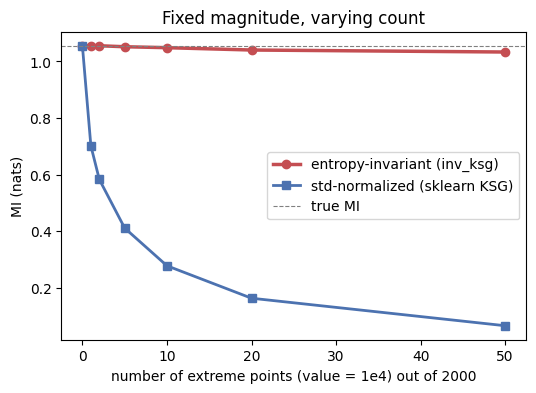

In [7]:
# Knob 1: how many extreme points (fixed magnitude = 1e4)?
outlier_counts = [0, 1, 2, 5, 10, 20, 50]
mi_inv_by_count = []
mi_std_by_count = []

for n_out in outlier_counts:
    x_test = x_clean.copy()
    if n_out > 0:
        idx = rng.choice(n2, n_out, replace=False)
        x_test[idx] = 1e4
    mi_inv_by_count.append(mutual_information_ksg(x_test, y_mi))
    mi_std_by_count.append(mi_std(x_test, y_mi))

fig, ax = plt.subplots()
ax.plot(outlier_counts, mi_inv_by_count, "o-", label="entropy-invariant (inv_ksg)", color="#C44E52", linewidth=2.5)
ax.plot(outlier_counts, mi_std_by_count, "s-", label="std-normalized (sklearn KSG)", color="#4C72B0", linewidth=2)
ax.axhline(y=true_mi, color="gray", linewidth=0.8, linestyle="--", label="true MI")
ax.set_xlabel("number of extreme points (value = 1e4) out of 2000")
ax.set_ylabel("MI (nats)")
ax.set_title("Fixed magnitude, varying count")
ax.legend()
plt.show()


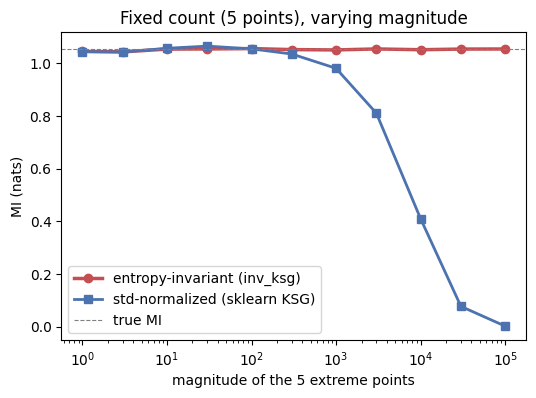

 magnitude   MI (entropy-inv)   MI (std-norm)
         1             1.0458          1.0448
         3             1.0439          1.0434
        10             1.0545          1.0576
        30             1.0551          1.0658
       100             1.0565          1.0554
       300             1.0526          1.0358
      1000             1.0513          0.9815
      3000             1.0551          0.8110
     10000             1.0521          0.4103
     30000             1.0546          0.0772
    100000             1.0549          0.0023


In [8]:
# Knob 2: how extreme (fixed count = 5 points)?
magnitudes = [1, 3, 10, 30, 100, 300, 1000, 3000, 1e4, 3e4, 1e5]
mi_inv_by_mag = []
mi_std_by_mag = []

for mag in magnitudes:
    x_test = x_clean.copy()
    idx = rng.choice(n2, 5, replace=False)
    x_test[idx] = mag
    mi_inv_by_mag.append(mutual_information_ksg(x_test, y_mi))
    mi_std_by_mag.append(mi_std(x_test, y_mi))

fig, ax = plt.subplots()
ax.semilogx(magnitudes, mi_inv_by_mag, "o-", label="entropy-invariant (inv_ksg)", color="#C44E52", linewidth=2.5)
ax.semilogx(magnitudes, mi_std_by_mag, "s-", label="std-normalized (sklearn KSG)", color="#4C72B0", linewidth=2)
ax.axhline(y=true_mi, color="gray", linewidth=0.8, linestyle="--", label="true MI")
ax.set_xlabel("magnitude of the 5 extreme points")
ax.set_ylabel("MI (nats)")
ax.set_title("Fixed count (5 points), varying magnitude")
ax.legend()
plt.show()

print(f"{'magnitude':>10} {'MI (entropy-inv)':>18} {'MI (std-norm)':>15}")
for mag, ei, sd in zip(magnitudes, mi_inv_by_mag, mi_std_by_mag):
    print(f"{mag:>10.0f} {ei:>18.4f} {sd:>15.4f}")


Two things to notice:

- **Count matters a lot**: even 1-2 points out of 2000 (0.05-0.1%) start pulling
  std-normalized MI down; by 20-50 points it's lost most of the true signal.
- **Magnitude has a threshold, not a gradual slope**: std-normalized MI stays fine while
  the "outliers" are only mildly larger than the bulk (a few std's out is normal for
  n=2000 samples), then drops sharply once they're extreme enough to dominate the
  variance calculation. `entropy-invariant` stays flat across the entire range in both
  sweeps -- the median the invariant measure is built on simply doesn't see points this
  rare, regardless of how extreme they are.

This -- not moderate skew or moderate outlier fractions -- is the practical scenario
where this package's normalization has a real, measurable edge: a handful of sensor
glitches, data-entry errors, or rare extreme events sitting in otherwise well-behaved
data. See `plot_cmi_comparison.ipynb` (section 7) for the same effect on conditional
mutual information, where a *single* extreme point can collapse a real dependency to
zero.


## 4. Mutual information and conditional entropy

Every function below defaults to `method="inv_ksg"` -- normalize, then shared-radius
count. No extra argument needed.


In [9]:
y = 2 * x + 0.1 * rng.normal(size=len(x))   # y depends on x, plus some noise

mi = mutual_information(x, y)              # inv_ksg by default
h_y_given_x = conditional_entropy(x, y)    # H(Y) - I(X;Y)_ksg, inv_ksg by default

print(f"I(x; y)   = {mi:.4f} nats")
print(f"H(y | x)  = {h_y_given_x:.4f} nats")

# Mutual information between independent variables should be close to zero
z_indep = rng.normal(size=len(x))
print(f"I(x; z)   = {mutual_information(x, z_indep):.4f} nats  (x, z independent)")

# Directly calling the estimator (equivalent to the default above)
print(f"I(x; y) via mutual_information_ksg directly = {mutual_information_ksg(x, y):.4f} nats")


I(x; y)   = 3.6784 nats
H(y | x)  = -2.4618 nats
I(x; z)   = -0.0138 nats  (x, z independent)
I(x; y) via mutual_information_ksg directly = 3.6784 nats


## 5. Multivariate quantities: joint entropy and MI matrices

Joint entropy of several variables at once still uses `entropy()` (there's no
MI-style differencing to bias-cancel for a single joint entropy value, so it stays
on the invariant-measure `"inv"` estimator). The pairwise MI matrix `MI()`, on the
other hand, is a collection of MI values -- so it defaults to `inv_ksg` per pair, same
as `mutual_information()`.


In [10]:
X = np.column_stack([x, y, z_indep])   # x, y=f(x)+noise, z_indep independent

h_joint = entropy(X)
print(f"H(x, y, z) = {h_joint:.4f} nats")

mi_matrix = MI(X)  # inv_ksg per pair, by default
print("\nPairwise mutual information matrix:")
print(np.round(mi_matrix, 3))


H(x, y, z) = 0.5462 nats



Pairwise mutual information matrix:
[[ 7.083  3.678 -0.014]
 [ 3.678  7.083 -0.017]
 [-0.014 -0.017  7.083]]


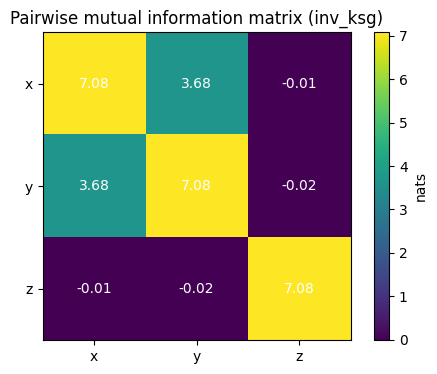

In [11]:
fig, ax = plt.subplots()
im = ax.imshow(mi_matrix, cmap="viridis")
ax.set_xticks(range(3)); ax.set_xticklabels(["x", "y", "z"])
ax.set_yticks(range(3)); ax.set_yticklabels(["x", "y", "z"])
ax.set_title("Pairwise mutual information matrix (inv_ksg)")
fig.colorbar(im, label="nats")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{mi_matrix[i, j]:.2f}", ha="center", va="center", color="white")
plt.show()


## 6. Partial information decomposition (redundancy, unique, synergy)

Given a target `Z` explained by two sources `X` and `Y`, the package decomposes their
joint mutual information into **redundant**, **unique**, and **synergistic**
contributions. These are built directly on `mutual_information()` /
`conditional_mutual_information()`, so they inherit the `inv_ksg` default too.


In [12]:
# A synergy example: z is only predictable from x AND y together
x2 = rng.normal(size=n)
y2 = rng.normal(size=n)
z2 = x2 * y2 + 0.05 * rng.normal(size=n)   # z2 needs both x2 and y2 -- neither alone predicts it well

red = redundancy(x2, y2, z2)
uniq_x, uniq_y = unique(x2, y2, z2)
syn = synergy(x2, y2, z2)

print(f"Redundancy(x2, y2 -> z2) = {red:.4f}")
print(f"Unique(x2 -> z2)         = {uniq_x:.4f}")
print(f"Unique(y2 -> z2)         = {uniq_y:.4f}")
print(f"Synergy(x2, y2 -> z2)    = {syn:.4f}")


Redundancy(x2, y2 -> z2) = 0.3782
Unique(x2 -> z2)         = 0.0000
Unique(y2 -> z2)         = 0.0122
Synergy(x2, y2 -> z2)    = 1.1676


Both `Unique` terms are small (neither `x2` nor `y2` alone is very informative about
`z2`), while `Synergy` dominates -- exactly what's expected from a target built from
the *product* of two independent sources.


## 7. Where to go next

- **Paper**: [An Invariant Measure for Differential Entropy](https://www.mdpi.com/1099-4300/28/3/301) -- full derivation and benchmarks.
- **Julia package**: [EntropyInvariant.jl](https://github.com/Entropy-Invariant/EntropyInvariant.jl) -- same estimator, Julia implementation (KSG/Frenzel-Pompe port in progress).
- **More examples in this repo**: `plot_cmi_comparison.ipynb` (thorough `inv` vs `inv_ksg` vs `ennemi` stress tests, including outlier contamination and manifold degeneracy), `plot_dependency_measures_comparison.ipynb`, `plot_entropy_normalization_comparison.ipynb` (the invariant-measure-vs-std story in depth), `plot_timeseries_skewed_heavy_outliers.ipynb`.
- **When to reach for `method="inv"` instead**: only when you need the individual entropy terms themselves (e.g. `H(X)`, `H(X,Y)` separately), not just their difference. For MI, CMI, NMI, interaction information, IQR, PID, and the MI/CMI matrices, `inv_ksg` (the default) is both more accurate and the recommended choice.
- **Questions / issues**: open a GitHub issue -- feedback on what to cover in future tutorials is very welcome.
